# Cell-Cell Communication in Crohn’s disease

Original paper: [Spatial fibroblast niches define Crohn’s fistulae](https://www.nature.com/articles/s41586-025-09744-y)

In [ ]:
#Load packages
import numpy as np
import pandas as pd
import scanpy as sc
import liana as li
import muon as mu
import anndata as ad
import seaborn as sns
import matplotlib.pyplot as plt
import plotnine as p9
import squidpy as sq
import os
from pathlib import Path

### Process all adata and add them to one list

In [2]:
adata_path = Path("/g/stegle/aalsayah/repos/data/xenium5k/agne_cd/")

In [ ]:
files = sorted(adata_path.glob("*.h5ad"))
adatas = [sc.read(f) for f in files]
for i, ad in enumerate(adatas, start=1):
    print(f"Processing {files[i-1].name} ({i}/{len(adatas)})")
    sc.pp.filter_cells(ad, min_genes=50)
    sc.pp.filter_genes(ad, min_cells=3)
    sc.pp.normalize_total(ad, target_sum=1e4)
    sc.pp.log1p(ad)

In [7]:
for adata in adatas:
    adata.obsm["spatial"] = np.column_stack(
        (adata.obs["x"].values, adata.obs["y"].values)
    )

In [ ]:
for sadata in adatas:
    sadata.obs["batch"] = sadata.obs["SAMPLE"].str.split("_").str[0]
    sadata.layers["counts"] = sadata.X.copy()
    sc.pp.normalize_total(sadata, target_sum=1e4)
    sc.pp.log1p(sadata)

### Explore the data

The data is collected from 19 samples, 7 healthy, 5 Fistula, and 7 ulcer patients. From different areas of colon and illeum. <br>
biopsies were sequenced in 3 separate runs, and batch effect was considered. <br>
 
<br>
Cells were annotated in 3 different levels, however, only level 0 and 3 are reported: <br>
* 8 totla cell types in coars annotation (level0). <br>
* 71 cell types in level 3 annotation.

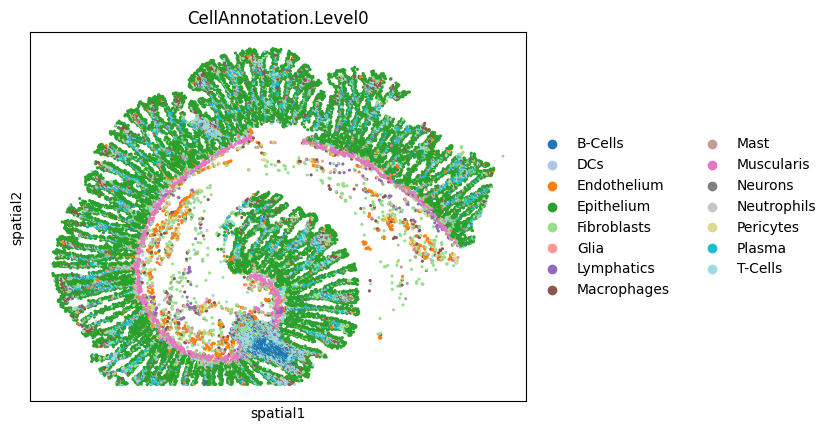

In [117]:
sc.pl.embedding(adatas[0], basis="spatial", color=["CellAnnotation.Level0"] , size=20)

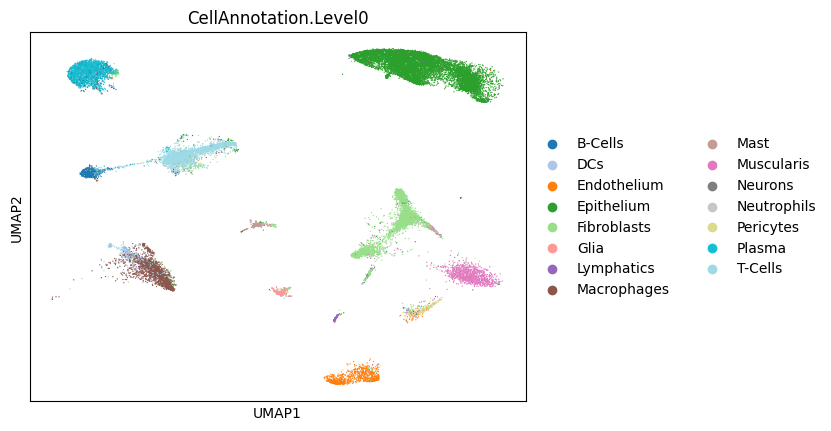

In [118]:
sc.pl.umap(adatas[0], color=["CellAnnotation.Level0"], palette='tab20')

---

### Find the right bandwidth for each adata (right bandwodh is when the average neighboring cells = 5)

In [ ]:
def find_bandwidth_for_k_neighbors(
    adata,
    k=5,
    start=5,
    end=40,
    interval_n=40,
    spatial_key="spatial",
):
    # Run bandwidth query
    plot, df = li.ut.query_bandwidth(
        coordinates=adata.obsm[spatial_key],
        start=start,
        end=end,
        interval_n=interval_n,
    )

    # Filter rows with desired average neighbors
    df_k = df[df["neighbours"] == k]

    if df_k.empty:
        raise ValueError(f"No bandwidth found with {k} neighbours")

    # If multiple rows:
    # choose the one with the minimum *highest* bandwidth
    best_row = df_k.loc[df_k["bandwith"].idxmin()]

    return best_row["bandwith"]

In [47]:
bandwidths = []

for adata in adatas:
    bw = find_bandwidth_for_k_neighbors(adata, k=5)
    print(f"Chosen bandwidth for {adata.obs['SAMPLE'].unique()[0]}: {bw} µm")
    bandwidths.append(bw)
    adata.uns["spatial_bandwidth_k5"] = bw

Chosen bandwidth for RUN1_SLIDE1_S2: 13.076923076923077 µm
Chosen bandwidth for RUN1_SLIDE1_S3: 13.974358974358974 µm
Chosen bandwidth for RUN1_SLIDE1_S5: 13.076923076923077 µm
Chosen bandwidth for RUN1_SLIDE2_S4: 13.076923076923077 µm
Chosen bandwidth for RUN1_SLIDE2_S5: 17.564102564102562 µm
Chosen bandwidth for RUN1_SLIDE2_S6: 12.179487179487179 µm
Chosen bandwidth for RUN1_SLIDE2_S7: 13.076923076923077 µm
Chosen bandwidth for RUN2_SLIDE1_S1: 19.358974358974358 µm
Chosen bandwidth for RUN2_SLIDE1_S2: 16.666666666666668 µm
Chosen bandwidth for RUN2_SLIDE1_S5: 15.76923076923077 µm
Chosen bandwidth for RUN2_SLIDE1_S6: 18.46153846153846 µm
Chosen bandwidth for RUN2_SLIDE1_S8: 28.333333333333336 µm
Chosen bandwidth for RUN3_SLIDE1_S1: 18.46153846153846 µm
Chosen bandwidth for RUN3_SLIDE1_S2: 16.666666666666668 µm
Chosen bandwidth for RUN3_SLIDE1_S3: 15.76923076923077 µm
Chosen bandwidth for RUN3_SLIDE1_S4: 22.94871794871795 µm
Chosen bandwidth for RUN3_SLIDE1_S5: 21.153846153846153 µm
Ch

### Run inflow (incl. all inflow pre-processing)

In [ ]:
lr_list = []
samples_done = []

for adata in adatas:
    # --- fetch metadata ---
    bw = adata.uns["spatial_bandwidth_k5"]
    s = adata.obs["SAMPLE"].unique()[0]

    # --- spatial neighbors on cells ---
    li.ut.spatial_neighbors(
        adata=adata,
        bandwidth=bw,
        spatial_key="spatial",
    )

    # --- Moran's I on cells ---
    sq.gr.spatial_autocorr(
        adata,
        mode="moran",
        use_raw=False,
        n_jobs=4,
        show_progress_bar=False,
    )

    # --- inflow ---
    lr = li.mt.inflow(
        adata,
        groupby="CellAnnotation.Level0",
        use_raw=False,
        resource_name='consensus'
    )

    # --- Moran's I on LR ---
    sq.gr.spatial_autocorr(
        lr,
        mode="moran",
        use_raw=False,
        n_jobs=4,
        show_progress_bar=False,
    )

    # --- filter spatially variable interactions ---
    svis = lr.uns["moranI"].index[
        (lr.uns["moranI"]["pval_norm_fdr_bh"] <= 0.05)
        & (lr.uns["moranI"]["I"] > 0.01)
    ]

    if len(svis) > 0:
        lr = lr[:, svis].copy()
    else:
        # skip samples with no significant LR
        continue

    # --- annotate + collect ---
    lr.obs["SAMPLE"] = s
    lr_list.append(lr)
    samples_done.append(s)

### To combine all lradata objects, we need to reraange their coords so they don't overlap

In [66]:
def calculate_grid_offsets(adatas, n_cols=4, margin_factor=1.2):
    """
    Calculate grid offsets to prevent overlap
    margin_factor: extra space between samples (1.2 = 20% margin)
    """
    # Get dimensions for each sample
    dimensions = []
    for adata in adatas:
        if 'spatial' in adata.obsm:
            coords = adata.obsm['spatial']
        else:
            coords = adata.obs[['x', 'y']].values
        
        # Get min and max
        x_min, x_max = coords[:, 0].min(), coords[:, 0].max()
        y_min, y_max = coords[:, 1].min(), coords[:, 1].max()
        
        width = x_max - x_min
        height = y_max - y_min
        
        dimensions.append({
            'width': width,
            'height': height,
            'x_min': x_min,
            'y_min': y_min,
            'x_range': (x_min, x_max),
            'y_range': (y_min, y_max)
        })
    
    # Calculate grid layout
    n_samples = len(adatas)
    n_rows = int(np.ceil(n_samples / n_cols))
    
    # Find max dimensions for uniform spacing
    max_width = max(d['width'] for d in dimensions)
    max_height = max(d['height'] for d in dimensions)
    
    # Calculate cell spacing with margins
    cell_width = max_width * margin_factor
    cell_height = max_height * margin_factor
    
    # Calculate offsets for each sample
    offsets = []
    for i in range(n_samples):
        row = i // n_cols
        col = i % n_cols
        
        x_offset = col * cell_width
        y_offset = row * cell_height
        
        offsets.append((x_offset, y_offset))
    
    return offsets, dimensions

In [67]:
def apply_offsets_to_adatas(adatas, offsets):
    """
    Apply calculated offsets to each AnnData object
    Returns new list of adatas with adjusted coordinates
    """
    adjusted_adatas = []
    
    for i, (adata, offset) in enumerate(zip(adatas, offsets)):
        # Create a copy to avoid modifying original
        adata_adj = adata.copy()
        
        # Get original coordinates
        if 'spatial' in adata_adj.obsm:
            coords = adata_adj.obsm['spatial'].copy()
        else:
            coords = adata_adj.obs[['x', 'y']].values
        
        # Apply offset: center the sample in its grid cell
        x_min, x_max = coords[:, 0].min(), coords[:, 0].max()
        y_min, y_max = coords[:, 1].min(), coords[:, 1].max()
        
        width = x_max - x_min
        height = y_max - y_min
        
        # Calculate centering offset
        center_x_offset = offset[0] - x_min
        center_y_offset = offset[1] - y_min
        
        # Apply transformation
        coords[:, 0] += center_x_offset
        coords[:, 1] += center_y_offset
        
        # Update the AnnData object
        adata_adj.obsm['spatial'] = coords
        adata_adj.obs['x'] = coords[:, 0]
        adata_adj.obs['y'] = coords[:, 1]
        
        # Store original coordinates for reference
        adata_adj.obs['x_original'] = adata.obs['x'].copy()
        adata_adj.obs['y_original'] = adata.obs['y'].copy()
        
        adjusted_adatas.append(adata_adj)
    
    return adjusted_adatas

In [ ]:
# Calculate offsets
offsets, dims = calculate_grid_offsets(lr_list, n_cols=4, margin_factor=1.3)

# Print offset plan
print("Grid layout plan:")
for i, (offset, dim) in enumerate(zip(offsets, dims)):
    print(f"Sample {i}: Offset = ({offset[0]:.0f}, {offset[1]:.0f}), "
          f"Size = {dim['width']:.0f} x {dim['height']:.0f}")

In [83]:
# Apply offsets
adjusted_adatas = apply_offsets_to_adatas(lr_list, offsets)

In [87]:
import anndata
lrdata_all = anndata.concat(
    adjusted_adatas,
    join="outer",
    label="batch2",
    keys=samples_done,
)

In [88]:
lrdata_all

AnnData object with n_obs × n_vars = 1291713 × 14119
    obs: 'cell', 'x', 'y', 'SAMPLE', 'TYPE', 'LOCATION', 'CellAnnotation.Level3', 'CellAnnotation.Level0', 'nCount_XENIUM_clean', 'nFeature_XENIUM_clean', 'n_genes', 'batch', 'x_original', 'y_original', 'batch2'
    obsm: 'X_umap', 'spatial'

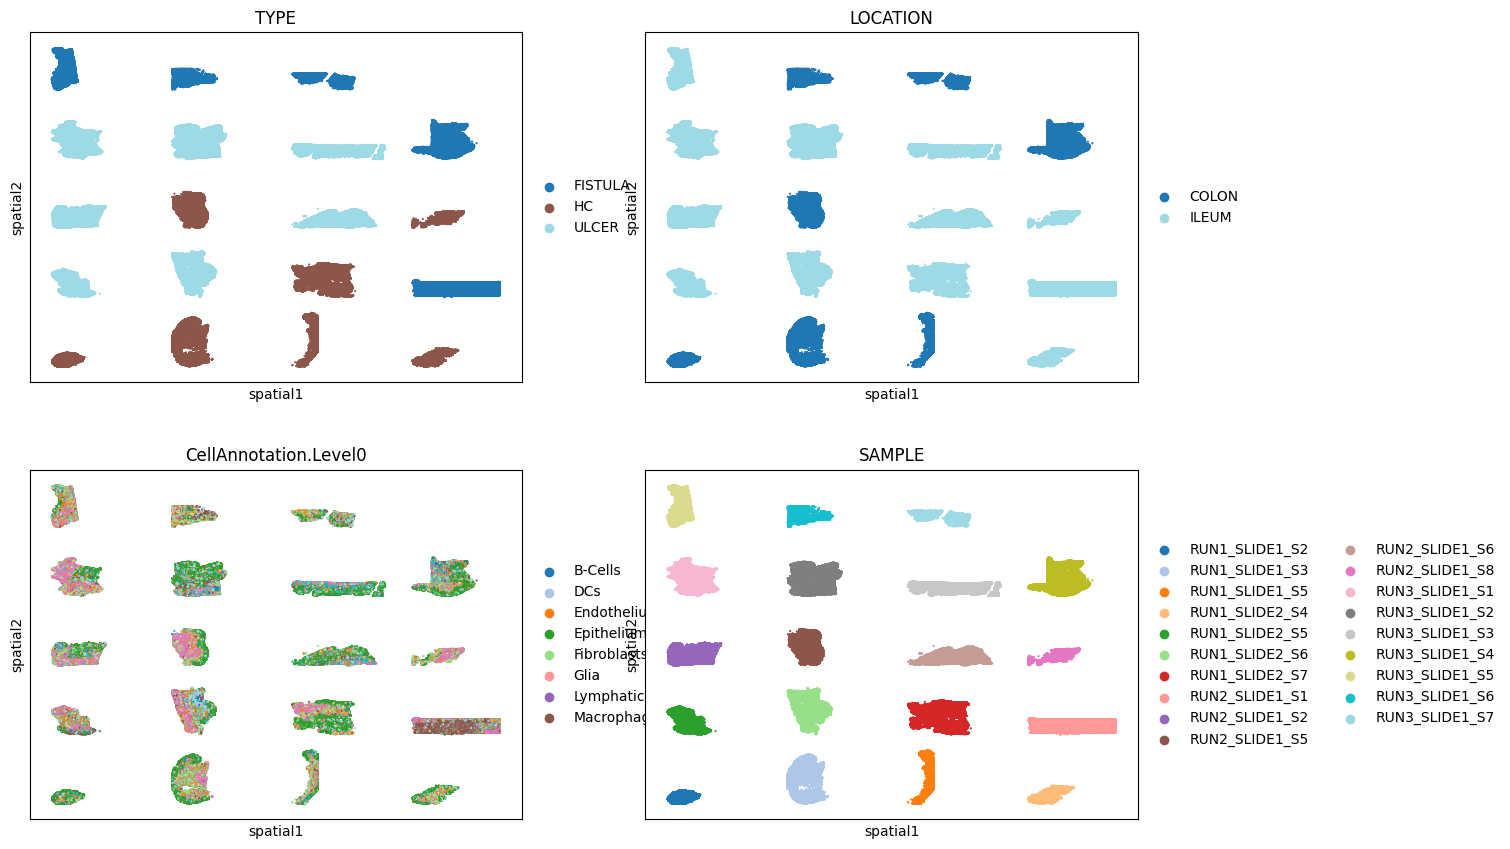

In [122]:
sc.pl.embedding(lrdata_all, basis="spatial", color=["TYPE", "LOCATION", "CellAnnotation.Level0", "SAMPLE"], ncols=2, size=10)

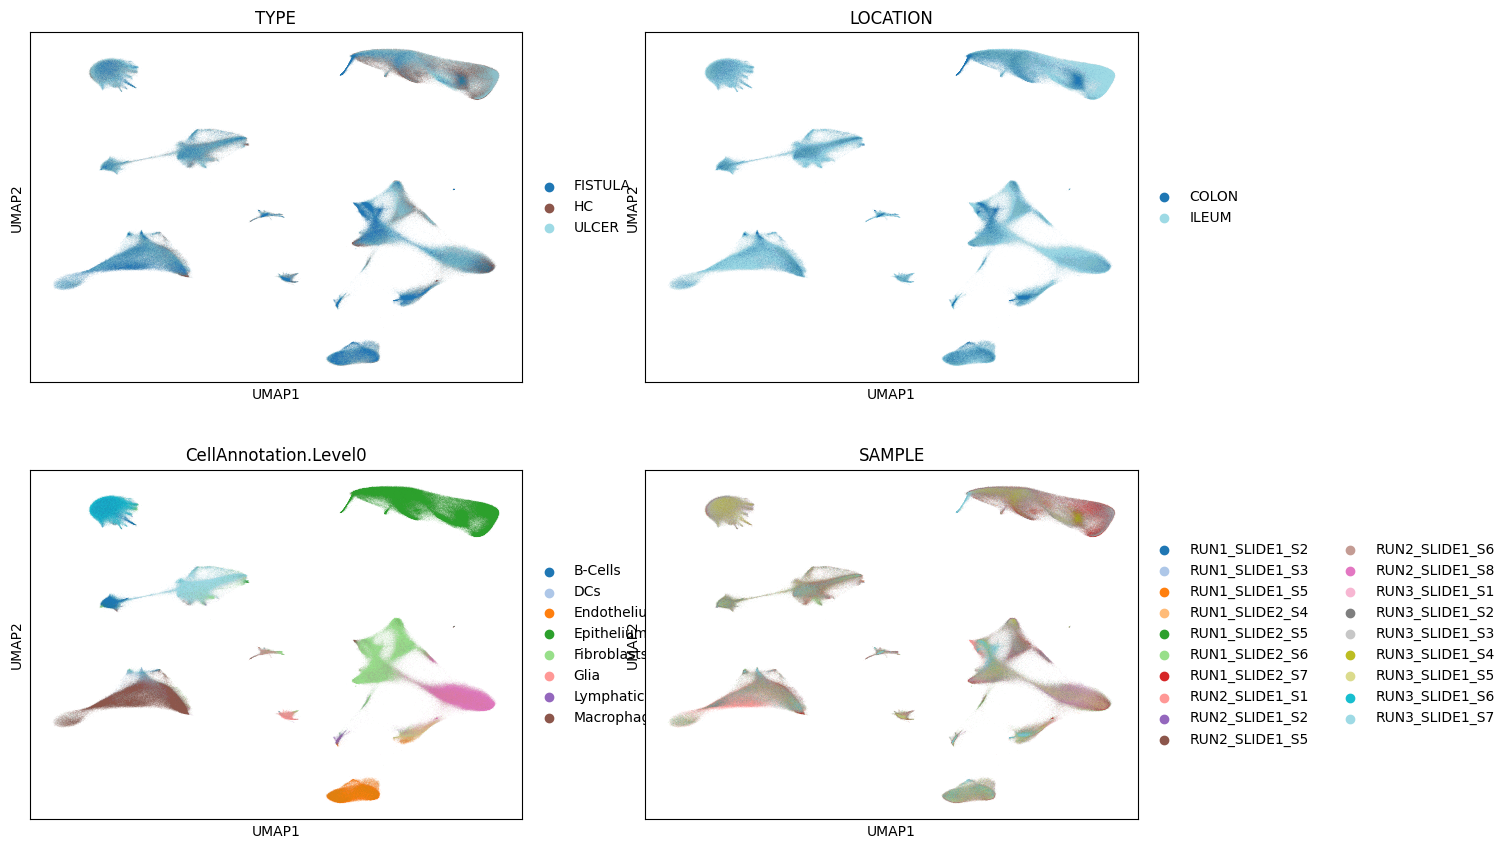

In [123]:
sc.pl.umap(lrdata_all, color=["TYPE", "LOCATION", "CellAnnotation.Level0", "SAMPLE"], ncols=2, palette='tab20')

### Save lrdata

In [90]:
lrdata_all.write_h5ad(adata_path / "lrdata.h5ad")

## Convert lrdata to mudata

In [91]:
from pathlib import Path
import scanpy as sc
import liana as li
import pandas as pd

In [ ]:
# adata_path = Path("/g/stegle/aalsayah/repos/data/xenium5k/agne_cd/")
# adata = sc.read_h5ad(adata_path / "lrdata.h5ad")

In [93]:
mdata = li.utils.anndata_to_mdata(
    adata = lrdata_all,
    groupby = "CellAnnotation.Level0",
    min_cells=10,
    by_var = True,
    verbose = True)

/home/alsayah/.local/lib/python3.10/site-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
/home/alsayah/.local/lib/python3.10/site-packages/mudata/_core/mudata.py:1461: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.


#### Add global obs

In [ ]:
TYPE = lrdata_all.obs["TYPE"].reindex(mdata.obs.index)
mdata.obs["TYPE"] = TYPE

In [105]:
SAMPLE = lrdata_all.obs["SAMPLE"].reindex(mdata.obs.index)
mdata.obs["SAMPLE"] = SAMPLE

In [107]:
LOCATION = lrdata_all.obs["LOCATION"].reindex(mdata.obs.index)
mdata.obs["LOCATION"] = LOCATION

In [109]:
CellAnnotation = lrdata_all.obs["CellAnnotation.Level3"].reindex(mdata.obs.index)
mdata.obs["CellAnnotation.Level3"] = CellAnnotation

In [110]:
CellAnnotation = lrdata_all.obs["CellAnnotation.Level0"].reindex(mdata.obs.index)
mdata.obs["CellAnnotation.Level0"] = CellAnnotation

In [113]:
mdata

MuData object with n_obs × n_vars = 1291713 × 11692
  obs:	'TYPE', 'SAMPLE', 'LOCATION', 'CellAnnotation.Level3', 'CellAnnotation.Level0'
  var:	'n_cells'
  15 modalities
    B-Cells:	1291713 x 767
      obs:	'cell', 'x', 'y', 'SAMPLE', 'TYPE', 'LOCATION', 'CellAnnotation.Level3', 'CellAnnotation.Level0', 'nCount_XENIUM_clean', 'nFeature_XENIUM_clean', 'n_genes', 'batch', 'x_original', 'y_original', 'batch2'
      var:	'n_cells'
      uns:	'TYPE_colors', 'LOCATION_colors', 'SAMPLE_colors'
      obsm:	'X_umap', 'spatial'
    DCs:	1291713 x 811
      obs:	'cell', 'x', 'y', 'SAMPLE', 'TYPE', 'LOCATION', 'CellAnnotation.Level3', 'CellAnnotation.Level0', 'nCount_XENIUM_clean', 'nFeature_XENIUM_clean', 'n_genes', 'batch', 'x_original', 'y_original', 'batch2'
      var:	'n_cells'
      uns:	'TYPE_colors', 'LOCATION_colors', 'SAMPLE_colors'
      obsm:	'X_umap', 'spatial'
    Endothelium:	1291713 x 903
      obs:	'cell', 'x', 'y', 'SAMPLE', 'TYPE', 'LOCATION', 'CellAnnotation.Level3', 'CellAnnotation.Level0', 'nCount_XENIUM_clean', 'nFeature_XENIUM_clean', 'n_genes', 'batch', 'x_original', 'y_original', 'batch2'
      var:	'n_cells'
      uns:	'TYPE_colors', 'LOCATION_colors', 'SAMPLE_colors'
      obsm:	'X_umap', 'spatial'
    Epithelium:	1291713 x 921
      obs:	'cell', 'x', 'y', 'SAMPLE', 'TYPE', 'LOCATION', 'CellAnnotation.Level3', 'CellAnnotation.Level0', 'nCount_XENIUM_clean', 'nFeature_XENIUM_clean', 'n_genes', 'batch', 'x_original', 'y_original', 'batch2'
      var:	'n_cells'
      uns:	'TYPE_colors', 'LOCATION_colors', 'SAMPLE_colors'
      obsm:	'X_umap', 'spatial'
    Fibroblasts:	1291713 x 1050
      obs:	'cell', 'x', 'y', 'SAMPLE', 'TYPE', 'LOCATION', 'CellAnnotation.Level3', 'CellAnnotation.Level0', 'nCount_XENIUM_clean', 'nFeature_XENIUM_clean', 'n_genes', 'batch', 'x_original', 'y_original', 'batch2'
      var:	'n_cells'
      uns:	'TYPE_colors', 'LOCATION_colors', 'SAMPLE_colors'
      obsm:	'X_umap', 'spatial'
    Glia:	1291713 x 700
      obs:	'cell', 'x', 'y', 'SAMPLE', 'TYPE', 'LOCATION', 'CellAnnotation.Level3', 'CellAnnotation.Level0', 'nCount_XENIUM_clean', 'nFeature_XENIUM_clean', 'n_genes', 'batch', 'x_original', 'y_original', 'batch2'
      var:	'n_cells'
      uns:	'TYPE_colors', 'LOCATION_colors', 'SAMPLE_colors'
      obsm:	'X_umap', 'spatial'
    Lymphatics:	1291713 x 724
      obs:	'cell', 'x', 'y', 'SAMPLE', 'TYPE', 'LOCATION', 'CellAnnotation.Level3', 'CellAnnotation.Level0', 'nCount_XENIUM_clean', 'nFeature_XENIUM_clean', 'n_genes', 'batch', 'x_original', 'y_original', 'batch2'
      var:	'n_cells'
      uns:	'TYPE_colors', 'LOCATION_colors', 'SAMPLE_colors'
      obsm:	'X_umap', 'spatial'
    Macrophages:	1291713 x 974
      obs:	'cell', 'x', 'y', 'SAMPLE', 'TYPE', 'LOCATION', 'CellAnnotation.Level3', 'CellAnnotation.Level0', 'nCount_XENIUM_clean', 'nFeature_XENIUM_clean', 'n_genes', 'batch', 'x_original', 'y_original', 'batch2'
      var:	'n_cells'
      uns:	'TYPE_colors', 'LOCATION_colors', 'SAMPLE_colors'
      obsm:	'X_umap', 'spatial'
    Mast:	1291713 x 690
      obs:	'cell', 'x', 'y', 'SAMPLE', 'TYPE', 'LOCATION', 'CellAnnotation.Level3', 'CellAnnotation.Level0', 'nCount_XENIUM_clean', 'nFeature_XENIUM_clean', 'n_genes', 'batch', 'x_original', 'y_original', 'batch2'
      var:	'n_cells'
      uns:	'TYPE_colors', 'LOCATION_colors', 'SAMPLE_colors'
      obsm:	'X_umap', 'spatial'
    Muscularis:	1291713 x 834
      obs:	'cell', 'x', 'y', 'SAMPLE', 'TYPE', 'LOCATION', 'CellAnnotation.Level3', 'CellAnnotation.Level0', 'nCount_XENIUM_clean', 'nFeature_XENIUM_clean', 'n_genes', 'batch', 'x_original', 'y_original', 'batch2'
      var:	'n_cells'
      uns:	'TYPE_colors', 'LOCATION_colors', 'SAMPLE_colors'
      obsm:	'X_umap', 'spatial'
    Neurons:	1291713 x 227
      obs:	'cell', 'x', 'y', 'SAMPLE', 'TYPE', 'LOCATION', 'CellAnnotation.Level3', 'CellAnnotation.Level0', 'nCount_XENIUM_clean', 'nFeature_XENIUM_clean', 'n_genes', 'batch', 'x_original', 'y_original', 'batch2'
      var:	'n_cells'
     

#### Save mudata

In [114]:
mdata.write_h5mu(adata_path / "mdata.h5mu")

/home/alsayah/.local/lib/python3.10/site-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
/home/alsayah/.local/lib/python3.10/site-packages/mudata/_core/mudata.py:1461: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
